# Historical GP validation and uncertainty calibration

## tl;dr

- This notebook evaluates the surrogate **out of sample** using 88 rolling one-step-ahead folds: each historical return is predicted using only evidence available before that return.
- Seven functions beat a historical-mean baseline on RMSE; F2 does not.
- Calibration is heterogeneous. F5–F7 under-cover at the nominal 95% level, while F1 and F8 are conservative.
- Every final Week 12 GP has at least one fitted parameter at a configured bound, so kernel-bound warnings are reported as evidence rather than suppressed.
- These results assess surrogate prediction and calibration. They do not replace optimisation-performance or recommendation-robustness evaluation.


## Context & Methods

The evaluation has three distinct questions:

1. **Optimisation performance:** did submitted queries improve the best observed objective within each function?
2. **Surrogate accuracy and calibration:** did a GP trained on the historical prefix predict the next returned value, and did its intervals cover at their nominal rates?
3. **Recommendation robustness:** does the proposed point remain stable under acquisition, GP-bound, and candidate-design changes?

### Key assumptions

The Matérn-5/2 GP, target normalisation, configured bounds, and canonical ledger pairing are held fixed. Each function has eleven rolling folds. Hyperparameters are re-estimated inside every fold with one optimiser restart; final Week 12 diagnostics use three restarts and the submission seeds. Adaptive historical queries are not an independent random test set, so the results are conditional predictive checks rather than generalisation guarantees.


In [1]:
from pathlib import Path
import subprocess
import sys
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    for candidate in Path.cwd().parents:
        if (candidate / 'Results' / 'query_output_ledger.csv').is_file():
            ROOT = candidate
            break
assert (ROOT / 'Results' / 'query_output_ledger.csv').is_file()
print(f'Repository: {ROOT}')

Repository: /Users/john-peteramewu/Documents/Codex/2026-08-07/understand-the-project-explain-the-structure/work/publish-week11.wwIJ2I


## Data

### 1. Recompute rolling validation from the immutable ledger

In [2]:
subprocess.run(
    [sys.executable, str(ROOT / 'Code' / 'run_gp_validation.py')],
    cwd=ROOT,
    check=True,
)
predictions = pd.read_csv(ROOT / 'Results' / 'gp_rolling_validation_predictions.csv')
metrics = pd.read_csv(ROOT / 'Results' / 'gp_validation_metrics.csv')
hyperparameters = pd.read_csv(ROOT / 'Results' / 'gp_final_hyperparameters.csv')
assert len(predictions) == 88
assert len(metrics) == len(hyperparameters) == 8
assert predictions.groupby('function').size().eq(11).all()
print('Validated 88 rolling folds: 11 per function.')

Saved 88 rolling folds, 8 metric rows, and 8 final hyperparameter rows
Validated 88 rolling folds: 11 per function.


## Results

### 2. Surrogate accuracy and interval calibration

In [3]:
display(metrics.round({
    'mae': 6, 'rmse': 6, 'naive_mean_rmse': 6, 'rmse_skill_vs_naive': 3,
    'coverage_50': 3, 'coverage_80': 3, 'coverage_95': 3,
    'mean_abs_z': 3, 'hyperparameter_bound_hit_rate': 3,
}))

,function,dimensions,rolling_folds,mae,rmse,naive_mean_rmse,rmse_skill_vs_naive,mean_absolute_standardized_error,mean_negative_log_predictive_density,coverage_50,coverage_80,coverage_95,mean_predictive_std,mean_abs_z,hyperparameter_bound_hit_rate,convergence_warning_folds
0,1,2,11,0.000131,0.000176,0.000258,0.317,0.135586,-6.532445,1.000,1.000,1.000,0.000678,0.151,0.636,7
1,2,2,11,0.121480,0.149677,0.136705,-0.095,0.572533,-0.540666,0.455,0.818,1.000,0.152807,0.874,0.091,1
2,3,3,11,0.020527,0.033313,0.047272,0.295,0.261898,7.808318,0.455,0.727,0.909,0.029330,2.122,0.909,10
3,4,4,11,1.619044,2.458890,8.550055,0.712,0.219811,1.968468,0.364,0.818,0.909,2.032682,0.845,0.455,5
4,5,4,11,193.808702,382.005320,680.252537,0.438,0.518681,9.351801,0.455,0.727,0.727,111.898677,1.819,1.000,11
5,6,5,11,0.172606,0.250453,0.513140,0.512,0.367565,-0.228521,0.455,0.545,0.727,0.156954,1.116,0.000,0
6,7,6,11,0.312685,0.456669,0.904467,0.495,0.814642,2.265717,0.273,0.545,0.636,0.154267,1.934,1.000,11
7,8,8,11,0.114568,0.138411,1.347948,0.897,0.112033,-0.404248,0.818,1.000,1.000,0.248976,0.480,1.000,11


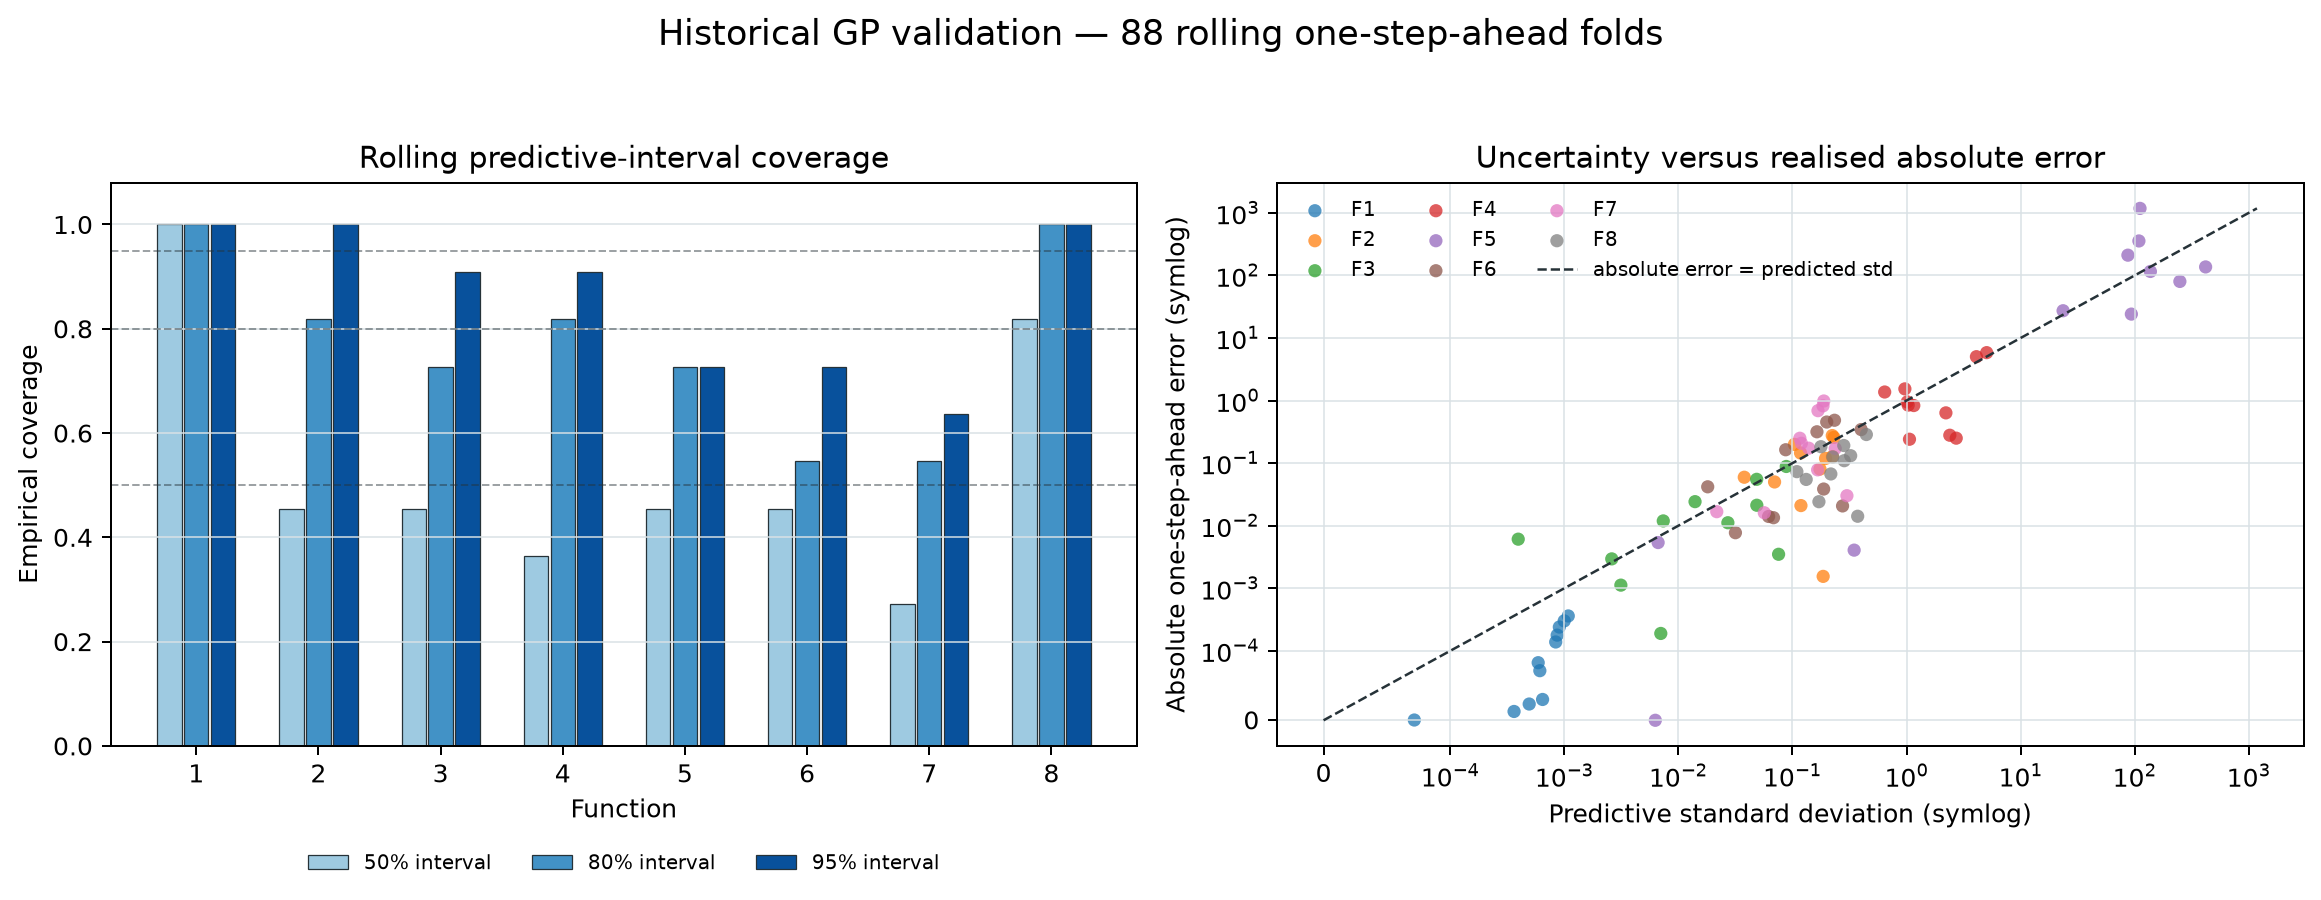

In [4]:
display(Image(filename=str(ROOT / 'Figures' / 'gp_rolling_validation_diagnostics.png')))

Coverage should be interpreted against nominal 50%, 80%, and 95% rates. With only eleven folds per function, one fold changes coverage by 9.1 percentage points. F5–F7 show material 95% under-coverage; F1 and F8 cover all folds and are conservative. The uncertainty/error panel uses symmetric-log axes because objective scales differ sharply across functions; it is not a cross-function ranking of raw errors.


### 3. Final fitted GP hyperparameters

In [5]:
columns = [
    'function', 'observation_count', 'constant_value', 'length_scales',
    'noise_level', 'constant_bound_status', 'length_scale_bound_status',
    'noise_bound_status', 'convergence_warning_count',
]
display(hyperparameters[columns])

,function,observation_count,constant_value,length_scales,noise_level,constant_bound_status,length_scale_bound_status,noise_bound_status,convergence_warning_count
0,1,21,1.493960,"[2.0,0.049832568721383086]",1.000000e-10,none,"[""upper"",""none""]",lower,2
1,2,21,0.990060,"[0.044434443931176425,2.0]",1.000000e-02,none,"[""none"",""upper""]",upper,2
2,3,26,1.941588,"[0.49612626132593257,2.0,0.1387612476023374]",1.968619e-03,none,"[""none"",""upper"",""none""]",none,1
3,4,41,19.171024,"[1.9567815059515523,1.8964489190213631,2.0,2.0]",1.337917e-03,none,"[""none"",""none"",""upper"",""upper""]",none,2
4,5,31,2.136158,"[2.0,0.5567353463141027,0.7556350244880167,0.4...",1.000000e-10,none,"[""upper"",""none"",""none"",""none""]",lower,5
5,6,31,4.708353,"[1.1532950024763338,0.8101781607009297,1.12019...",1.223909e-03,none,"[""none"",""none"",""none"",""none"",""upper""]",none,1
6,7,41,0.828655,"[0.6437970321073466,0.46801610211796874,1.2949...",1.000000e-10,none,"[""none"",""none"",""none"",""none"",""none"",""none""]",lower,1
7,8,51,0.990294,"[1.2370848372214467,2.0,1.0102185808209312,2.0...",1.000000e-10,none,"[""none"",""upper"",""none"",""upper"",""upper"",""upper""...",lower,6


Longer fitted length scales imply slower variation along a coordinate under this kernel; a value at the upper bound means the data support a smoother direction than the configured search permitted. Near-zero noise estimates indicate that the fitted model attributes little independent noise, not that the black box is proven noiseless. Boundary estimates and convergence warnings indicate weak identification or restrictive bounds and motivate the separate wider-bound sensitivity analysis.


## Takeaways

1. Optimisation success is sparse: only five of the 88 recovered weekly returns set a new incumbent. This does not measure GP accuracy.
2. Rolling validation shows useful predictive skill for seven functions relative to a historical-mean baseline, but F2 is worse than that baseline.
3. Interval calibration is not uniformly reliable. Under-coverage for F5–F7 means their uncertainty estimates should not be treated as calibrated probabilities without adjustment.
4. Recommendation robustness is a separate property. Week 12 sensitivity finds stable recommendations for F4/F5 and model-dependent behaviour elsewhere; it cannot identify the best acquisition without returned outcomes.
5. All findings are conditional on eleven adaptive folds per function, the recovered ledger, the Matérn model family, and the frozen environment. They do not establish global optimality or independent-test-set generalisation.
